In [ ]:
%pip install timm==0.9.12 torch torchmetrics torchvision --index-url https://download.pytorch.org/whl/cu121 --upgrade tqdm opencv-python pillow --upgrade

In [1]:
import torch
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0)) 

GPU name: NVIDIA GeForce RTX 4060 Ti


In [2]:
# Cell 1
from pathlib import Path
import hashlib, cv2, random, time
import numpy as np
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF
from tqdm import tqdm
from collections import Counter
from torch.utils.data import Dataset, DataLoader
import timm
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_recall_fscore_support
)
import torch.nn.functional as F
import json
import pandas as pd

# ⚙️ SET YOUR DATA ROOT
DATA_ROOT = Path(r"G:/My Drive/CLPD-MF-Dataset")  
assert DATA_ROOT.exists(), f"Dataset folder not found at {DATA_ROOT}"
print("Found dataset root:", DATA_ROOT)


c:\Users\Mohamed Hazem\anaconda3\envs\dlclass\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found dataset root: G:\My Drive\CLPD-MF-Dataset


In [4]:
def list_images_and_labels(root):
    """
    List all images with labels and magnifications from the new folder structure.
    
    Structure:
    G:/My Drive/CLPD-MF-Dataset/
    ├── MF/
    │   └── Patient Name/
    │       ├── x5/
    │       ├── x10/
    │       └── x20/
    └── Non-MF/
        ├── B cell Lymphoma/
        │   └── Patient Name/
        │       ├── x5/
        │       ├── x10/
        │       └── x20/
        ├── PLEVA-PLC/
        └── pseudolymphoma/
    """
    rows = []
    root = Path(root)
    
    # Process MF folder
    mf_dir = root / "MF"
    if mf_dir.exists():
        for patient_dir in mf_dir.iterdir():
            if not patient_dir.is_dir(): continue
            
            patient_name = patient_dir.name
            # Look for x10 and x20 subfolders
            for mag in ['x10', 'x20']:
                mag_dir = patient_dir / mag
                if mag_dir.exists() and mag_dir.is_dir():
                    # Find all .tif images in this magnification folder
                    for img_path in mag_dir.glob('*.tif'):
                        rows.append({
                            'path': img_path,
                            'label': 'MF',
                            'patient': patient_name,
                            'mag': mag,
                            'subtype': None  # MF has no subtype
                        })
    
    # Process Non-MF folder with subtypes
    nonmf_dir = root / "Non-MF"
    if nonmf_dir.exists():
        # Each subfolder is a disease subtype
        for subtype_dir in nonmf_dir.iterdir():
            if not subtype_dir.is_dir(): continue
            
            subtype = subtype_dir.name  # B cell Lymphoma, PLEVA-PLC, or pseudolymphoma
            
            # Each patient within the subtype
            for patient_dir in subtype_dir.iterdir():
                if not patient_dir.is_dir(): continue
                
                patient_name = patient_dir.name
                
                # Look for x10 and x20 subfolders
                for mag in ['x10', 'x20']:
                    mag_dir = patient_dir / mag
                    if mag_dir.exists() and mag_dir.is_dir():
                        # Find all .tif images in this magnification folder
                        for img_path in mag_dir.glob('*.tif'):
                            rows.append({
                                'path': img_path,
                                'label': 'Non-MF',
                                'patient': patient_name,
                                'mag': mag,
                                'subtype': subtype
                            })
    
    return rows

# Load all images
print("\n" + "="*80)
print("LOADING DATASET")
print("="*80 + "\n")

all_images = list_images_and_labels(DATA_ROOT)

print(f"Total images found: {len(all_images)}")
print(f"\nMagnification distribution:")
mag_counts = Counter([r['mag'] for r in all_images])
for mag, count in sorted(mag_counts.items()):
    print(f"  {mag}: {count} images")

print(f"\nLabel distribution:")
label_counts = Counter([r['label'] for r in all_images])
for label, count in sorted(label_counts.items()):
    print(f"  {label}: {count} images")

# Count unique patients
unique_patients = len(set(r['patient'] for r in all_images))
mf_patients = len(set(r['patient'] for r in all_images if r['label'] == 'MF'))
nonmf_patients = len(set(r['patient'] for r in all_images if r['label'] == 'Non-MF'))
print(f"\nUnique patients:")
print(f"  Total: {unique_patients}")
print(f"  MF: {mf_patients}")
print(f"  Non-MF: {nonmf_patients}")

# Show Non-MF subtypes distribution
print(f"\nNon-MF subtypes:")
nonmf_images = [r for r in all_images if r['label'] == 'Non-MF']
subtype_counts = Counter([r['subtype'] for r in nonmf_images])
for subtype, count in sorted(subtype_counts.items()):
    subtype_patients = len(set(r['patient'] for r in nonmf_images if r['subtype'] == subtype))
    print(f"  {subtype}: {count} images ({subtype_patients} patients)")




LOADING DATASET

Total images found: 1145

Magnification distribution:
  x10: 426 images
  x20: 719 images

Label distribution:
  MF: 491 images
  Non-MF: 654 images

Unique patients:
  Total: 67
  MF: 24
  Non-MF: 43

Non-MF subtypes:
  B cell Lymphoma: 291 images (16 patients)
  PLEVA-PLC: 217 images (17 patients)
  pseudolymphoma: 146 images (10 patients)


In [5]:
# Cell 3
PATCH_CACHE = Path('./patch_cache')
PATCH_CACHE.mkdir(exist_ok=True)

def extract_and_cache_patches(img_path, patch_size=512, stride=256, 
                              min_foreground_ratio=0.05, max_patches_per_image=200):
    key = hashlib.sha1(str(img_path).encode()).hexdigest()
    cache_dir = PATCH_CACHE / key
    if cache_dir.exists() and any(cache_dir.iterdir()):
        return sorted([str(p) for p in cache_dir.glob('*.jpg')])

    cache_dir.mkdir(parents=True, exist_ok=True)
    img = Image.open(img_path).convert('RGB')
    W,H = img.size
    patches = []

    for y in range(0, H-patch_size+1, stride):
        for x in range(0, W-patch_size+1, stride):
            crop = img.crop((x,y,x+patch_size,y+patch_size))
            arr = np.asarray(crop)
            v = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
            fg_ratio = (v > 10).mean()
            if fg_ratio < min_foreground_ratio: continue
            fname = cache_dir / f'{x}_{y}.jpg'
            crop.save(fname, quality=90)
            patches.append(str(fname))
            if len(patches) >= max_patches_per_image: break
        if len(patches) >= max_patches_per_image: break
    return patches


In [6]:
# Cell 4
class MFHistologyDataset(Dataset):
    def __init__(self, rows, mag='x20', mode='train', patching=True, patch_size=512,
                 stride=256, transforms=None, max_patches_per_image=100):
        self.rows = [r for r in rows if (mag is None or r['mag']==mag)]
        self.mode = mode
        self.patching = patching
        self.patch_size = patch_size
        self.stride = stride
        self.max_patches_per_image = max_patches_per_image
        self.transforms = transforms
        labels = sorted(list({r['label'] for r in self.rows}))
        self.label2idx = {lab:i for i,lab in enumerate(labels)}


        self.items = []
        for r in self.rows:
            if self.patching:
                patches = extract_and_cache_patches(r['path'], patch_size=self.patch_size,
                                                    stride=self.stride, max_patches_per_image=self.max_patches_per_image)
                for p in patches:
                    self.items.append({'img': p, 'label': self.label2idx[r['label']], 'source': str(r['path'])})
            else:
                self.items.append({'img': str(r['path']), 'label': self.label2idx[r['label']], 'source': str(r['path'])})
        if len(self.items)==0:
            print("Warning: dataset empty for magnification", mag)

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        it = self.items[idx]
        img = Image.open(it['img']).convert('RGB')
        if self.transforms: img = self.transforms(img)
        return img, it['label'], it['source']


train_tf = transforms.Compose([
    transforms.Resize((512,512), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((512,512), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])


In [7]:
# Cell 5
def patient_split_stratified(rows, mag='x20', val_frac=0.15, seed=42):

    # group patients by class
    cls_map = {}
    for r in rows:
        if r['mag'] != mag: continue
        cls_map.setdefault(r['label'], {}).setdefault(r['patient'], []).append(r)

    # Now stratify
    train_rows, val_rows = [], []

    rng = random.Random(seed)

    for cls, patients_dict in cls_map.items():
        patients = list(patients_dict.keys())
        rng.shuffle(patients)

        n = len(patients)
        n_val = max(1, int(n * val_frac))

        val_p = set(patients[:n_val]) 

        for p, rlist in patients_dict.items():
            if p in val_p:  
                val_rows += rlist
            else: 
                train_rows += rlist
    return train_rows, val_rows



# x20
train_rows_20, val_rows_20 = patient_split_stratified(all_images, mag='x20', val_frac=0.15)

train_ds_20 = MFHistologyDataset(train_rows_20, mag='x20', mode='train', patching=True, transforms=train_tf)
val_ds_20   = MFHistologyDataset(val_rows_20, mag='x20', mode='val', patching=True, transforms=val_tf)
print(len(train_ds_20), len(val_ds_20))

# x10
train_rows_10, val_rows_10 = patient_split_stratified(all_images, mag='x10', val_frac=0.15)

train_ds_10 = MFHistologyDataset(train_rows_10, mag='x10', mode='train', patching=True, transforms=train_tf)
val_ds_10   = MFHistologyDataset(val_rows_10, mag='x10', mode='val', patching=True, transforms=val_tf)
print(len(train_ds_10), len(val_ds_10))



33696 5130
20088 2916


In [8]:
# Cell 6

def create_model(model_name='resnet50', pretrained=True, num_classes=2, dropout=0.2):
    model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes, drop_rate=dropout)
    return model

# Choose model_name = 'resnet50' or 'swin_base_patch4_window12_384' (Swin) or tf_efficientnet_b2
model_name_10x = 'resnet50'
model_name_20x = 'resnet50'
device = torch.device('cuda')

# --- Create separate models for x10 and x20 ---
model_10 = create_model(model_name=model_name_10x, pretrained=True, num_classes=2).to(device)
model_20 = create_model(model_name=model_name_20x, pretrained=True, num_classes=2).to(device)

# --- Compute class weights for each dataset separately ---
def get_class_weights(train_ds):
    counts = {}
    for it in train_ds.items:
        counts[it['label']] = counts.get(it['label'], 0) + 1
    total = sum(counts.values())
    weights = [total/counts.get(i,1) for i in range(len(counts))]
    return torch.tensor(weights, dtype=torch.float).to(device)

weights_10 = get_class_weights(train_ds_10)
weights_20 = get_class_weights(train_ds_20)

# --- Loss functions ---
criterion_10 = nn.CrossEntropyLoss(weight=weights_10)
criterion_20 = nn.CrossEntropyLoss(weight=weights_20)

# --- Optimizers ---
optimizer_10 = optim.AdamW(model_10.parameters(), lr=3e-4, weight_decay=1e-4)
optimizer_20 = optim.AdamW(model_20.parameters(), lr=3e-4, weight_decay=1e-4)

# --- GradScalers for mixed precision ---
scaler_10 = torch.amp.GradScaler('cuda')
scaler_20 = torch.amp.GradScaler('cuda')


In [8]:
# Cell 7

# Save Path
save_path = Path("C:/Users/Mohamed Hazem/Graduation Project/Dr. Rushdy/CLPD Dr. Kariman/Mycosis-Fungoides-Classifier/Trained Models")

def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    running_loss = 0.0
    total = 0
    correct = 0
    for imgs, labels, _src in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return running_loss/total, correct/total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    total = 0
    correct = 0
    all_preds=[]
    all_labels=[]
    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    acc = correct/total if total>0 else 0
    return running_loss/total if total>0 else 0, acc, torch.cat(all_preds) if all_preds else torch.tensor([]), torch.cat(all_labels) if all_labels else torch.tensor([])

# dataloaders
train_loader_10 = DataLoader(train_ds_10, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
val_loader_10   = DataLoader(val_ds_10, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)
train_loader_20 = DataLoader(train_ds_20, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
val_loader_20   = DataLoader(val_ds_20, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

# Create separate models
model_10 = create_model(model_name=model_name_10x, pretrained=True, num_classes=2).to(device)
model_20 = create_model(model_name=model_name_20x, pretrained=True, num_classes=2).to(device)

# Separate optimizers and scalers
optimizer_10 = optim.AdamW(model_10.parameters(), lr=1e-4, weight_decay=1e-4)
optimizer_20 = optim.AdamW(model_20.parameters(), lr=1e-4, weight_decay=1e-4)
scaler_10 = torch.amp.GradScaler('cuda')
scaler_20 = torch.amp.GradScaler('cuda')

# Separate best validation accuracy trackers
best_val_acc_10 = 0.0
best_val_acc_20 = 0.0

EPOCHS = 7

for epoch in range(EPOCHS):
    t0 = time.time()

    # --- Train x10 model ---
    train_loss_10, train_acc_10 = train_one_epoch(model_10, train_loader_10, optimizer_10, criterion_10, device, scaler_10)
    val_loss_10, val_acc_10, _, _ = validate(model_10, val_loader_10, criterion_10, device)

    # --- Train x20 model ---
    train_loss_20, train_acc_20 = train_one_epoch(model_20, train_loader_20, optimizer_20, criterion_20, device, scaler_20)
    val_loss_20, val_acc_20, _, _ = validate(model_20, val_loader_20, criterion_20, device)

    t1 = time.time()
    print(f"Epoch {epoch+1}/{EPOCHS} | x10 train_acc {train_acc_10:.4f} val_acc {val_acc_10:.4f} | "
          f"x20 train_acc {train_acc_20:.4f} val_acc {val_acc_20:.4f} | time {(t1-t0):.1f}s")

    # Save best models
    if val_acc_10 > best_val_acc_10:
        best_val_acc_10 = val_acc_10
        torch.save(model_10.state_dict(), save_path / f'model_{model_name_10x}_x10.pth')
        print("Saved best x10 model.")
    if val_acc_20 > best_val_acc_20:
        best_val_acc_20 = val_acc_20
        torch.save(model_20.state_dict(), save_path / f'model_{model_name_20x}_x20.pth')
        print("Saved best x20 model.")



C:\Users\Mohamed Hazem\AppData\Local\Temp\ipykernel_11260\1405145201.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/7 | x10 train_acc 0.8108 val_acc 0.5048 | x20 train_acc 0.8344 val_acc 0.8154 | time 1682.8s
Saved best x10 model.
Saved best x20 model.
Epoch 2/7 | x10 train_acc 0.8749 val_acc 0.6334 | x20 train_acc 0.8959 val_acc 0.8380 | time 1637.1s
Saved best x10 model.
Saved best x20 model.
Epoch 3/7 | x10 train_acc 0.9017 val_acc 0.6687 | x20 train_acc 0.9229 val_acc 0.7957 | time 1681.4s
Saved best x10 model.
Epoch 4/7 | x10 train_acc 0.9222 val_acc 0.7202 | x20 train_acc 0.9372 val_acc 0.8497 | time 1731.0s
Saved best x10 model.
Saved best x20 model.
Epoch 5/7 | x10 train_acc 0.9367 val_acc 0.6862 | x20 train_acc 0.9465 val_acc 0.8433 | time 1729.1s
Epoch 6/7 | x10 train_acc 0.9420 val_acc 0.6883 | x20 train_acc 0.9553 val_acc 0.8121 | time 1713.7s
Epoch 7/7 | x10 train_acc 0.9497 val_acc 0.6855 | x20 train_acc 0.9621 val_acc 0.8261 | time 1634.8s


In [9]:
# Cell 8
print("Loading models...")
model_10.load_state_dict(torch.load(
    f"C:/Users/Mohamed Hazem/Graduation Project/Dr. Rushdy/CLPD Dr. Kariman/Mycosis-Fungoides-Classifier/Trained Models/model_{model_name_10x}_x10.pth"
))
model_10.to(device).eval()
print(f"✓ Loaded x10 model ({model_name_10x})")

model_20.load_state_dict(torch.load(
    f"C:/Users/Mohamed Hazem/Graduation Project/Dr. Rushdy/CLPD Dr. Kariman/Mycosis-Fungoides-Classifier/Trained Models/model_{model_name_20x}_x20.pth"
))
model_20.to(device).eval()
print(f"✓ Loaded x20 model ({model_name_20x})")

# --- Prediction per model ---
def predict_image_by_patches(img_path, model, device, patch_size=512, stride=256, transforms=val_tf):
    """
    Predicts class for one image by extracting patches.
    Returns mean probability and predicted class.
    """
    patches = extract_and_cache_patches(img_path, patch_size=patch_size, stride=stride, max_patches_per_image=200)
    if len(patches) == 0:
        return None
    
    probs = []
    with torch.no_grad():
        for p in patches:
            x = transforms(Image.open(p).convert('RGB')).unsqueeze(0).to(device)
            out = model(x)
            prob = F.softmax(out, dim=1).cpu().numpy()[0]
            probs.append(prob)
    
    mean_prob = np.array(probs).mean(axis=0)
    pred_class = mean_prob.argmax()
    
    return {
        'pred': int(pred_class), 
        'prob': mean_prob.tolist(), 
        'num_patches': len(patches),
        'all_patch_probs': probs  # Keep all patch predictions for analysis
    }

# --- Combined prediction with WEIGHTED average (2:1 for x20:x10) ---
def combined_prediction_weighted(img_paths_dict, model_10, model_20, device, 
                                 weight_x20=2.0, weight_x10=1.0):
    """
    img_paths_dict: {'x10': Path(...), 'x20': Path(...)}
    Returns combined probability with weighted average (default 2:1 for x20:x10)
    """
    weighted_probs = []
    weights = []
    results = {'x10': None, 'x20': None}
    
    if 'x10' in img_paths_dict and img_paths_dict['x10'].exists():
        res10 = predict_image_by_patches(img_paths_dict['x10'], model_10, device)
        if res10:
            weighted_probs.append(np.array(res10['prob']) * weight_x10)
            weights.append(weight_x10)
            results['x10'] = res10
    
    if 'x20' in img_paths_dict and img_paths_dict['x20'].exists():
        res20 = predict_image_by_patches(img_paths_dict['x20'], model_20, device)
        if res20:
            weighted_probs.append(np.array(res20['prob']) * weight_x20)
            weights.append(weight_x20)
            results['x20'] = res20
    
    if len(weighted_probs) == 0:
        return None
    
    # Weighted average
    combined_prob = np.sum(weighted_probs, axis=0) / np.sum(weights)
    combined_class = combined_prob.argmax()
    
    return {
        'pred': int(combined_class), 
        'prob': combined_prob.tolist(),
        'individual_results': results,
        'weights_used': {'x10': weight_x10 if results['x10'] else 0, 
                        'x20': weight_x20 if results['x20'] else 0}
    }

# --- Original equal-weight prediction (for comparison) ---
def combined_prediction(img_paths_dict, model_10, model_20, device):
    """
    Original equal-weight prediction (1:1)
    """
    return combined_prediction_weighted(img_paths_dict, model_10, model_20, device, 
                                       weight_x20=1.0, weight_x10=1.0)

print("\n✓ Prediction functions ready")
print("  - predict_image_by_patches: Single magnification prediction")
print("  - combined_prediction: Equal weight (1:1)")
print("  - combined_prediction_weighted: Custom weights (default 2:1)")


Loading models...


C:\Users\Mohamed Hazem\AppData\Local\Temp\ipykernel_20900\3537333462.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_10.load_state_dict(torch.load(


✓ Loaded x10 model (resnet50)


C:\Users\Mohamed Hazem\AppData\Local\Temp\ipykernel_20900\3537333462.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_20.load_state_dict(torch.load(


✓ Loaded x20 model (resnet50)

✓ Prediction functions ready
  - predict_image_by_patches: Single magnification prediction
  - combined_prediction: Equal weight (1:1)
  - combined_prediction_weighted: Custom weights (default 2:1)


In [ ]:
# Cell 9 - Evaluate on Specific Patients
def evaluate_model_comprehensive(model, data_rows, mag, device, transforms=val_tf):
    """
    Comprehensive evaluation of a model on a dataset.
    Returns predictions, ground truth, and metrics.
    """
    print(f"\nEvaluating {mag} model on {len(data_rows)} images...")
    
    y_true = []
    y_pred = []
    y_probs = []
    patient_results = {}
    
    for row in tqdm(data_rows, desc=f"Evaluating {mag}"):
        result = predict_image_by_patches(row['path'], model, device, transforms=transforms)
        
        if result is None:
            continue
        
        # Ground truth
        true_label = 0 if row['label'] == 'MF' else 1
        y_true.append(true_label)
        y_pred.append(result['pred'])
        y_probs.append(result['prob'][1])  # Probability of Non-MF class
        
        # Store per-patient results
        patient = row['patient']
        if patient not in patient_results:
            patient_results[patient] = {
                'true_label': row['label'],
                'predictions': [],
                'probs': []
            }
        patient_results[patient]['predictions'].append(result['pred'])
        patient_results[patient]['probs'].append(result['prob'])
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=[0, 1], zero_division=0
    )
    
    # Weighted metrics
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    # ROC AUC
    try:
        fpr, tpr, thresholds = roc_curve(y_true, y_probs)
        roc_auc = auc(fpr, tpr)
    except:
        fpr, tpr, thresholds, roc_auc = None, None, None, None
    
    # Precision-Recall curve
    try:
        prec_curve, rec_curve, pr_thresholds = precision_recall_curve(y_true, y_probs)
        avg_precision = average_precision_score(y_true, y_probs)
    except:
        prec_curve, rec_curve, pr_thresholds, avg_precision = None, None, None, None
    
    results = {
        'magnification': mag,
        'num_images': len(y_true),
        'accuracy': accuracy,
        'precision_per_class': precision.tolist(),
        'recall_per_class': recall.tolist(),
        'f1_per_class': f1.tolist(),
        'support_per_class': support.tolist(),
        'precision_weighted': precision_w,
        'recall_weighted': recall_w,
        'f1_weighted': f1_w,
        'confusion_matrix': cm.tolist(),
        'roc_auc': roc_auc,
        'avg_precision': avg_precision,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_probs': y_probs,
        'roc_curve': {'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds},
        'pr_curve': {'precision': prec_curve, 'recall': rec_curve, 'thresholds': pr_thresholds},
        'patient_results': patient_results
    }
    
    return results


# ==============================================================================
# Define test patients with their full paths and expected labels
# ==============================================================================
test_patient_paths = [
    {
        'path': Path(r"G:/My Drive/CLPD-MF-Dataset/MF/noura 60-61-3-24/61"),
        'expected_label': 'MF'
    },
    {
        'path': Path(r"G:/My Drive/CLPD-MF-Dataset/MF/ahmed 21-22-23-3-24/21"),
        'expected_label': 'MF'
    },
    {
        'path': Path(r"G:/My Drive/CLPD-MF-Dataset/MF/ahmed 21-22-23-3-24/22"),
        'expected_label': 'MF'
    },
    {
        'path': Path(r"G:/My Drive/CLPD-MF-Dataset/MF/esmat 87-88-3-24/87"),
        'expected_label': 'MF'
    },
    {
        'path': Path(r"G:/My Drive/CLPD-MF-Dataset/MF/elsayed 276-277-1-24/276"),
        'expected_label': 'MF'
    },
    {
        'path': Path(r"G:/My Drive/CLPD-MF-Dataset/MF/esmat 87-88-3-24/88"),
        'expected_label': 'MF'
    },
    {
        'path': Path(r"G:/My Drive/CLPD-MF-Dataset/Non-MF/PLEVA-PLC/kareem 244-243-1-24/244"),
        'expected_label': 'Non-MF'
    },
    {
        'path': Path(r"G:/My Drive/CLPD-MF-Dataset/Non-MF/PLEVA-PLC/kareem 244-243-1-24/243"),
        'expected_label': 'Non-MF'
    }
]

# ==============================================================================
# Collect all images from these specific patients
# ==============================================================================
print("\n" + "="*80)
print("COLLECTING IMAGES FROM SPECIFIC PATIENTS")
print("="*80 + "\n")

eval_x10_images = []
eval_x20_images = []

for patient_info in test_patient_paths:
    patient_path = patient_info['path']
    expected_label = patient_info['expected_label']
    patient_name = patient_path.name
    
    print(f"Processing: {patient_name}")
    print(f"  Expected label: {expected_label}")
    
    if not patient_path.exists():
        print(f"  ⚠️  WARNING: Patient folder not found!")
        continue
    
    # Get x10 images
    x10_dir = patient_path / "x10"
    if x10_dir.exists():
        x10_tifs = list(x10_dir.glob("*.tif"))
        print(f"  Found {len(x10_tifs)} x10 images")
        
        for img_path in x10_tifs:
            eval_x10_images.append({
                'path': img_path,
                'label': expected_label,
                'patient': patient_name,
                'mag': 'x10',
                'subtype': None if expected_label == 'MF' else patient_path.parent.name
            })
    else:
        print(f"  ⚠️  No x10 folder found")
    
    # Get x20 images
    x20_dir = patient_path / "x20"
    if x20_dir.exists():
        x20_tifs = list(x20_dir.glob("*.tif"))
        print(f"  Found {len(x20_tifs)} x20 images")
        
        for img_path in x20_tifs:
            eval_x20_images.append({
                'path': img_path,
                'label': expected_label,
                'patient': patient_name,
                'mag': 'x20',
                'subtype': None if expected_label == 'MF' else patient_path.parent.name
            })
    else:
        print(f"  ⚠️  No x20 folder found")
    
    print()

# ==============================================================================
# Summary of collected images
# ==============================================================================
print("="*80)
print("EVALUATION SET SUMMARY")
print("="*80 + "\n")

print(f"Total patients: {len(test_patient_paths)}")
print(f"Total x10 images: {len(eval_x10_images)}")
print(f"Total x20 images: {len(eval_x20_images)}")

# Show breakdown by label
x10_mf = sum(1 for r in eval_x10_images if r['label'] == 'MF')
x10_nonmf = len(eval_x10_images) - x10_mf
x20_mf = sum(1 for r in eval_x20_images if r['label'] == 'MF')
x20_nonmf = len(eval_x20_images) - x20_mf

print(f"\nx10 breakdown:")
print(f"  MF: {x10_mf} images")
print(f"  Non-MF: {x10_nonmf} images")

print(f"\nx20 breakdown:")
print(f"  MF: {x20_mf} images")
print(f"  Non-MF: {x20_nonmf} images")

# Show per-patient breakdown
print(f"\nPer-patient image counts:")
from collections import defaultdict
patient_counts = defaultdict(lambda: {'x10': 0, 'x20': 0, 'label': None})

for img in eval_x10_images:
    patient_counts[img['patient']]['x10'] += 1
    patient_counts[img['patient']]['label'] = img['label']

for img in eval_x20_images:
    patient_counts[img['patient']]['x20'] += 1
    patient_counts[img['patient']]['label'] = img['label']

for patient, counts in patient_counts.items():
    print(f"  {patient} ({counts['label']}): {counts['x10']} x10, {counts['x20']} x20")

# ==============================================================================
# Verify we have images to evaluate
# ==============================================================================
if len(eval_x10_images) == 0 and len(eval_x20_images) == 0:
    print("\n" + "="*80)
    print("⚠️  ERROR: No images found!")
    print("="*80)
    print("\nPlease check:")
    print("  1. Patient folder paths are correct")
    print("  2. Folders contain x10/ and x20/ subfolders")
    print("  3. Subfolders contain .tif files")
    raise ValueError("No images found for evaluation")

# ==============================================================================
# Run comprehensive evaluation
# ==============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE MODEL EVALUATION")
print("="*80)

if len(eval_x10_images) > 0:
    print(f"\nEvaluating x10 model...")
    eval_x10 = evaluate_model_comprehensive(
        model_10, 
        eval_x10_images,
        'x10', 
        device
    )
else:
    print("\n⚠️  Skipping x10 evaluation (no images)")
    eval_x10 = None

if len(eval_x20_images) > 0:
    print(f"\nEvaluating x20 model...")
    eval_x20 = evaluate_model_comprehensive(
        model_20, 
        eval_x20_images,
        'x20', 
        device
    )
else:
    print("\n⚠️  Skipping x20 evaluation (no images)")
    eval_x20 = None

# ==============================================================================
# Print detailed results per patient
# ==============================================================================
print("\n" + "="*80)
print("PER-PATIENT RESULTS")
print("="*80 + "\n")

label_map = {0: "MF", 1: "Non-MF"}

for patient_info in test_patient_paths:
    patient_name = patient_info['path'].name
    expected_label = patient_info['expected_label']
    
    print(f"Patient: {patient_name}")
    print(f"Expected: {expected_label}")
    print("-" * 60)
    
    # x10 results for this patient
    if eval_x10 and patient_name in eval_x10['patient_results']:
        patient_x10 = eval_x10['patient_results'][patient_name]
        x10_preds = patient_x10['predictions']
        x10_probs = patient_x10['probs']
        
        # Average predictions
        avg_x10_prob = np.mean(x10_probs, axis=0)
        majority_x10_pred = max(set(x10_preds), key=x10_preds.count)
        
        print(f"  x10 Results ({len(x10_preds)} images):")
        print(f"    Majority Vote: {label_map[majority_x10_pred]}")
        print(f"    Avg Probability: MF={avg_x10_prob[0]:.3f}, Non-MF={avg_x10_prob[1]:.3f}")
        print(f"    Individual predictions: {[label_map[p] for p in x10_preds]}")
    else:
        print(f"  x10 Results: No images")
    
    # x20 results for this patient
    if eval_x20 and patient_name in eval_x20['patient_results']:
        patient_x20 = eval_x20['patient_results'][patient_name]
        x20_preds = patient_x20['predictions']
        x20_probs = patient_x20['probs']
        
        # Average predictions
        avg_x20_prob = np.mean(x20_probs, axis=0)
        majority_x20_pred = max(set(x20_preds), key=x20_preds.count)
        
        print(f"  x20 Results ({len(x20_preds)} images):")
        print(f"    Majority Vote: {label_map[majority_x20_pred]}")
        print(f"    Avg Probability: MF={avg_x20_prob[0]:.3f}, Non-MF={avg_x20_prob[1]:.3f}")
        print(f"    Individual predictions: {[label_map[p] for p in x20_preds]}")
    else:
        print(f"  x20 Results: No images")
    
    print()

# ==============================================================================
# Print overall summary
# ==============================================================================
print("="*80)
print("OVERALL EVALUATION SUMMARY")
print("="*80)

if eval_x10:
    print(f"\nx10 Model:")
    print(f"  Images evaluated: {eval_x10['num_images']}")
    print(f"  Accuracy: {eval_x10['accuracy']:.4f}")
    print(f"  F1-Score (weighted): {eval_x10['f1_weighted']:.4f}")
    if eval_x10['roc_auc']:
        print(f"  ROC AUC: {eval_x10['roc_auc']:.4f}")
    print(f"\n  Per-Class Metrics:")
    for i, class_name in enumerate(['MF', 'Non-MF']):
        print(f"    {class_name}:")
        print(f"      Precision: {eval_x10['precision_per_class'][i]:.4f}")
        print(f"      Recall: {eval_x10['recall_per_class'][i]:.4f}")
        print(f"      F1-Score: {eval_x10['f1_per_class'][i]:.4f}")
        print(f"      Support: {eval_x10['support_per_class'][i]}")
    
    cm = np.array(eval_x10['confusion_matrix'])
    print(f"\n  Confusion Matrix:")
    print(f"                Predicted MF  Predicted Non-MF")
    print(f"    Actual MF          {cm[0,0]:6d}         {cm[0,1]:12d}")
    print(f"    Actual Non-MF      {cm[1,0]:6d}         {cm[1,1]:12d}")

if eval_x20:
    print(f"\nx20 Model:")
    print(f"  Images evaluated: {eval_x20['num_images']}")
    print(f"  Accuracy: {eval_x20['accuracy']:.4f}")
    print(f"  F1-Score (weighted): {eval_x20['f1_weighted']:.4f}")
    if eval_x20['roc_auc']:
        print(f"  ROC AUC: {eval_x20['roc_auc']:.4f}")
    print(f"\n  Per-Class Metrics:")
    for i, class_name in enumerate(['MF', 'Non-MF']):
        print(f"    {class_name}:")
        print(f"      Precision: {eval_x20['precision_per_class'][i]:.4f}")
        print(f"      Recall: {eval_x20['recall_per_class'][i]:.4f}")
        print(f"      F1-Score: {eval_x20['f1_per_class'][i]:.4f}")
        print(f"      Support: {eval_x20['support_per_class'][i]}")
    
    cm = np.array(eval_x20['confusion_matrix'])
    print(f"\n  Confusion Matrix:")
    print(f"                Predicted MF  Predicted Non-MF")
    print(f"    Actual MF          {cm[0,0]:6d}         {cm[0,1]:12d}")
    print(f"    Actual Non-MF      {cm[1,0]:6d}         {cm[1,1]:12d}")

print("\n" + "="*80)
print("✓ Evaluation complete! Variables 'eval_x10' and 'eval_x20' are ready.")
print("="*80)


COLLECTING IMAGES FROM SPECIFIC PATIENTS

Processing: 61
  Expected label: MF
  Found 5 x10 images
  Found 6 x20 images

Processing: 21
  Expected label: MF
  Found 9 x10 images
  Found 15 x20 images

Processing: 22
  Expected label: MF
  Found 6 x10 images
  Found 10 x20 images

Processing: 244
  Expected label: Non-MF
  Found 5 x10 images
  Found 9 x20 images

EVALUATION SET SUMMARY

Total patients: 4
Total x10 images: 25
Total x20 images: 40

x10 breakdown:
  MF: 20 images
  Non-MF: 5 images

x20 breakdown:
  MF: 31 images
  Non-MF: 9 images

Per-patient image counts:
  61 (MF): 5 x10, 6 x20
  21 (MF): 9 x10, 15 x20
  22 (MF): 6 x10, 10 x20
  244 (Non-MF): 5 x10, 9 x20

COMPREHENSIVE MODEL EVALUATION

Evaluating x10 model...

Evaluating x10 model on 25 images...


Evaluating x10: 100%|██████████| 25/25 [00:11<00:00,  2.25it/s]



Evaluating x20 model...

Evaluating x20 model on 40 images...


Evaluating x20: 100%|██████████| 40/40 [00:17<00:00,  2.34it/s]


PER-PATIENT RESULTS

Patient: 61
Expected: MF
------------------------------------------------------------
  x10 Results (5 images):
    Majority Vote: MF
    Avg Probability: MF=0.755, Non-MF=0.245
    Individual predictions: ['MF', 'MF', 'MF', 'MF', 'MF']
  x20 Results (6 images):
    Majority Vote: MF
    Avg Probability: MF=0.604, Non-MF=0.396
    Individual predictions: ['MF', 'Non-MF', 'MF', 'MF', 'MF', 'MF']

Patient: 21
Expected: MF
------------------------------------------------------------
  x10 Results (9 images):
    Majority Vote: Non-MF
    Avg Probability: MF=0.085, Non-MF=0.915
    Individual predictions: ['Non-MF', 'Non-MF', 'Non-MF', 'Non-MF', 'Non-MF', 'Non-MF', 'Non-MF', 'Non-MF', 'Non-MF']
  x20 Results (15 images):
    Majority Vote: Non-MF
    Avg Probability: MF=0.216, Non-MF=0.784
    Individual predictions: ['Non-MF', 'Non-MF', 'Non-MF', 'Non-MF', 'Non-MF', 'MF', 'Non-MF', 'Non-MF', 'Non-MF', 'MF', 'Non-MF', 'Non-MF', 'Non-MF', 'Non-MF', 'Non-MF']

Patient: 

In [11]:
# Cell 10 - Visualization Functions
def plot_confusion_matrix(cm, class_names=['MF', 'Non-MF'], title='Confusion Matrix', ax=None):
    """Plot confusion matrix"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.set_title(title)
    
    return ax

def plot_roc_curve(eval_results, ax=None):
    """Plot ROC curve"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    if eval_results['roc_curve']['fpr'] is not None:
        fpr = eval_results['roc_curve']['fpr']
        tpr = eval_results['roc_curve']['tpr']
        roc_auc = eval_results['roc_auc']
        
        ax.plot(fpr, tpr, linewidth=2, 
                label=f"{eval_results['magnification']} (AUC = {roc_auc:.3f})")
        ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title('ROC Curve')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    return ax

def plot_precision_recall_curve(eval_results, ax=None):
    """Plot Precision-Recall curve"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    if eval_results['pr_curve']['precision'] is not None:
        prec = eval_results['pr_curve']['precision']
        rec = eval_results['pr_curve']['recall']
        avg_prec = eval_results['avg_precision']
        
        ax.plot(rec, prec, linewidth=2, 
                label=f"{eval_results['magnification']} (AP = {avg_prec:.3f})")
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title('Precision-Recall Curve')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    return ax

def plot_class_distribution(eval_results, ax=None):
    """Plot class distribution"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    support = eval_results['support_per_class']
    classes = ['MF', 'Non-MF']
    
    ax.bar(classes, support, color=['#e74c3c', '#27ae60'], alpha=0.7)
    ax.set_ylabel('Number of Samples')
    ax.set_title(f'Class Distribution - {eval_results["magnification"]}')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add counts on top of bars
    for i, v in enumerate(support):
        ax.text(i, v + max(support)*0.02, str(v), ha='center', va='bottom', fontweight='bold')
    
    return ax

def plot_metrics_comparison(eval_x10, eval_x20):
    """Compare metrics between x10 and x20 models"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
    
    # Accuracy comparison
    ax = axes[0, 0]
    models = ['x10', 'x20']
    accuracies = [eval_x10['accuracy'], eval_x20['accuracy']]
    bars = ax.bar(models, accuracies, color=['#3498db', '#e67e22'], alpha=0.7)
    ax.set_ylabel('Accuracy')
    ax.set_title('Overall Accuracy')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    for i, (bar, acc) in enumerate(zip(bars, accuracies)):
        ax.text(bar.get_x() + bar.get_width()/2, acc + 0.02, 
                f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # F1-Score comparison
    ax = axes[0, 1]
    f1_scores = [eval_x10['f1_weighted'], eval_x20['f1_weighted']]
    bars = ax.bar(models, f1_scores, color=['#3498db', '#e67e22'], alpha=0.7)
    ax.set_ylabel('F1-Score')
    ax.set_title('Weighted F1-Score')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    for i, (bar, f1) in enumerate(zip(bars, f1_scores)):
        ax.text(bar.get_x() + bar.get_width()/2, f1 + 0.02, 
                f'{f1:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Per-class F1 comparison
    ax = axes[1, 0]
    x = np.arange(2)
    width = 0.35
    ax.bar(x - width/2, eval_x10['f1_per_class'], width, label='x10', 
           color='#3498db', alpha=0.7)
    ax.bar(x + width/2, eval_x20['f1_per_class'], width, label='x20', 
           color='#e67e22', alpha=0.7)
    ax.set_ylabel('F1-Score')
    ax.set_title('F1-Score per Class')
    ax.set_xticks(x)
    ax.set_xticklabels(['MF', 'Non-MF'])
    ax.legend()
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # ROC AUC comparison
    ax = axes[1, 1]
    if eval_x10['roc_auc'] and eval_x20['roc_auc']:
        aucs = [eval_x10['roc_auc'], eval_x20['roc_auc']]
        bars = ax.bar(models, aucs, color=['#3498db', '#e67e22'], alpha=0.7)
        ax.set_ylabel('AUC')
        ax.set_title('ROC AUC')
        ax.set_ylim([0, 1])
        ax.grid(True, alpha=0.3, axis='y')
        for i, (bar, auc_val) in enumerate(zip(bars, aucs)):
            ax.text(bar.get_x() + bar.get_width()/2, auc_val + 0.02, 
                    f'{auc_val:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    return fig


GENERATING VISUALIZATIONS



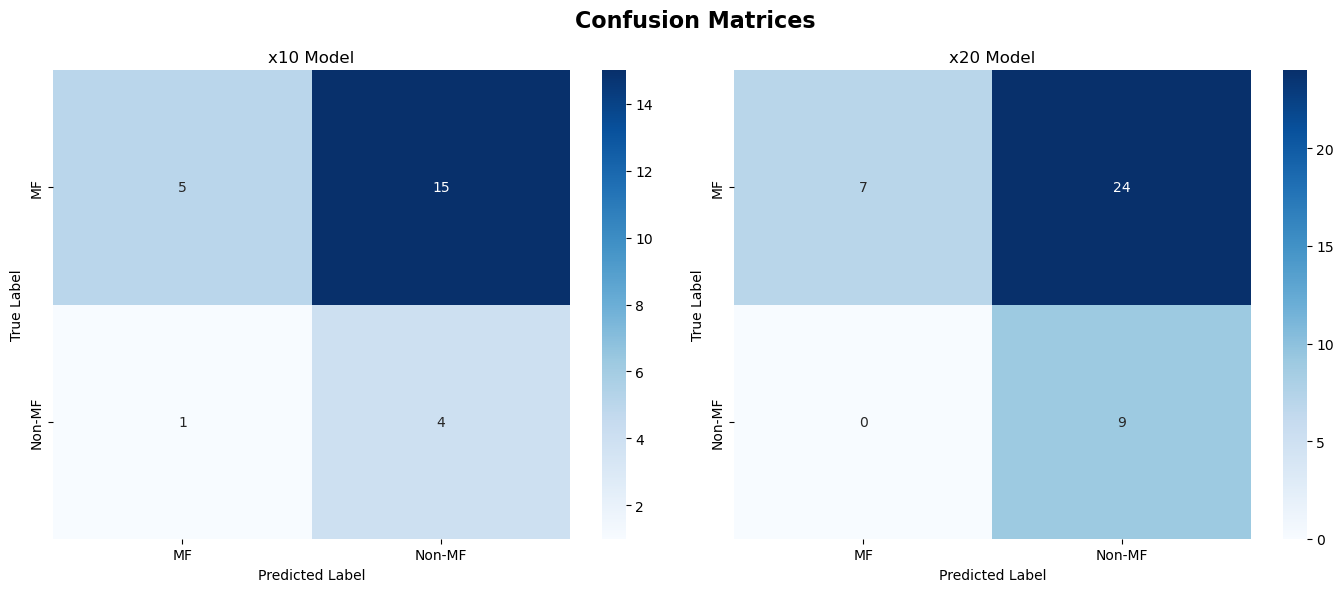

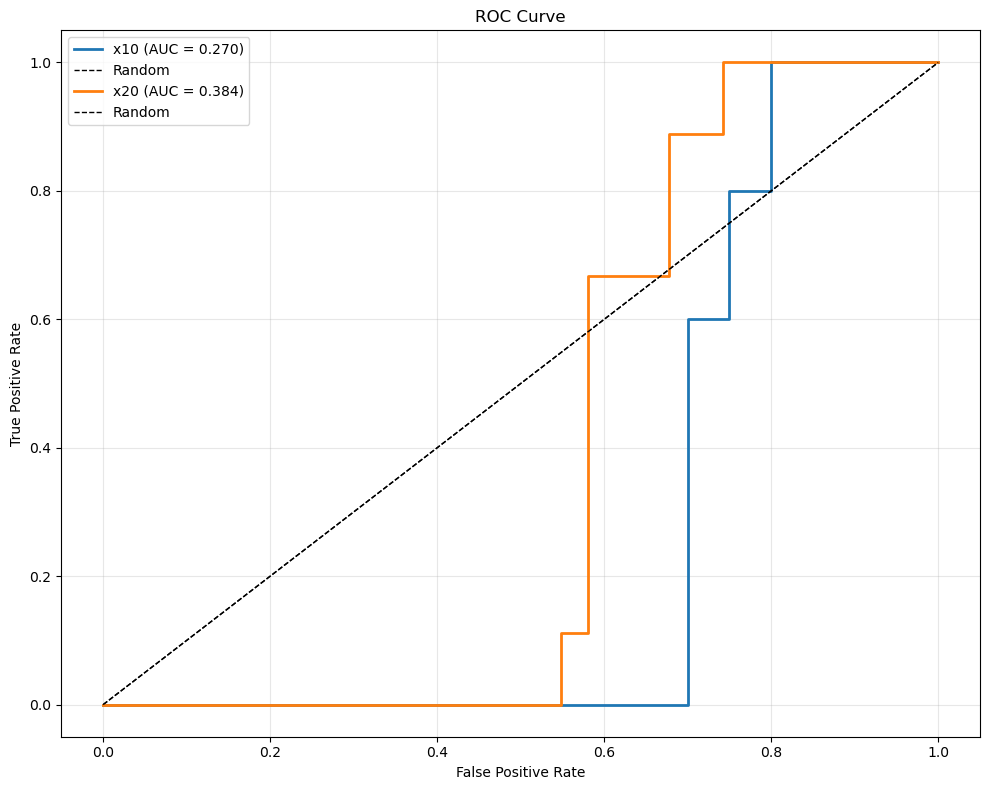

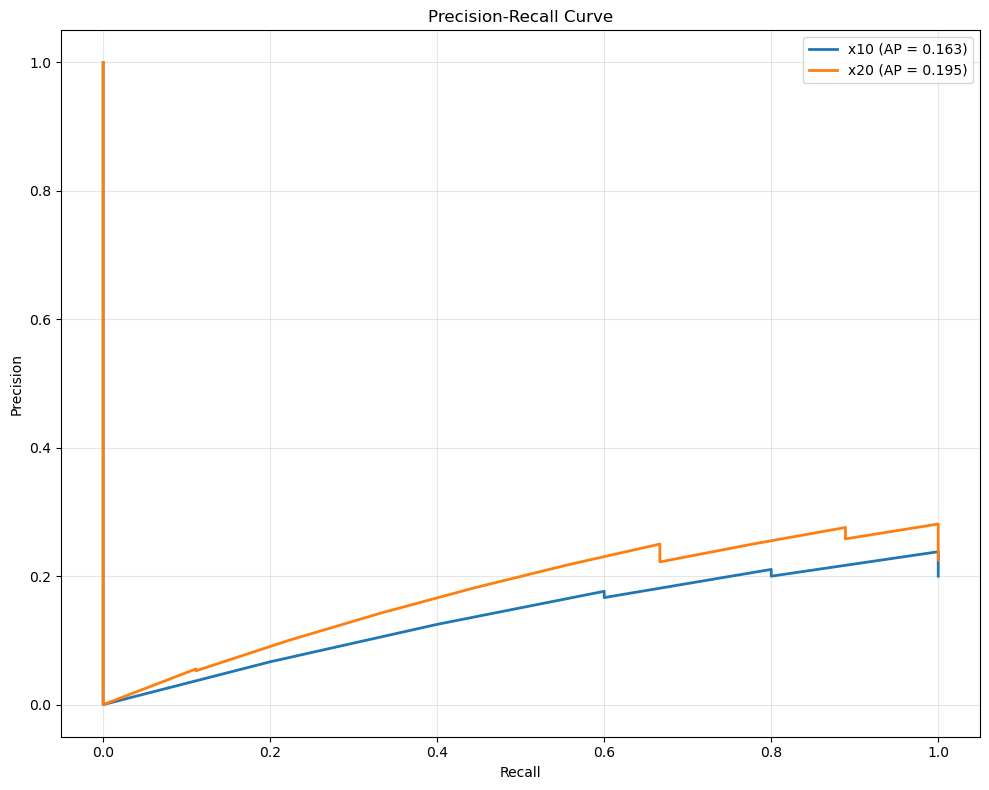

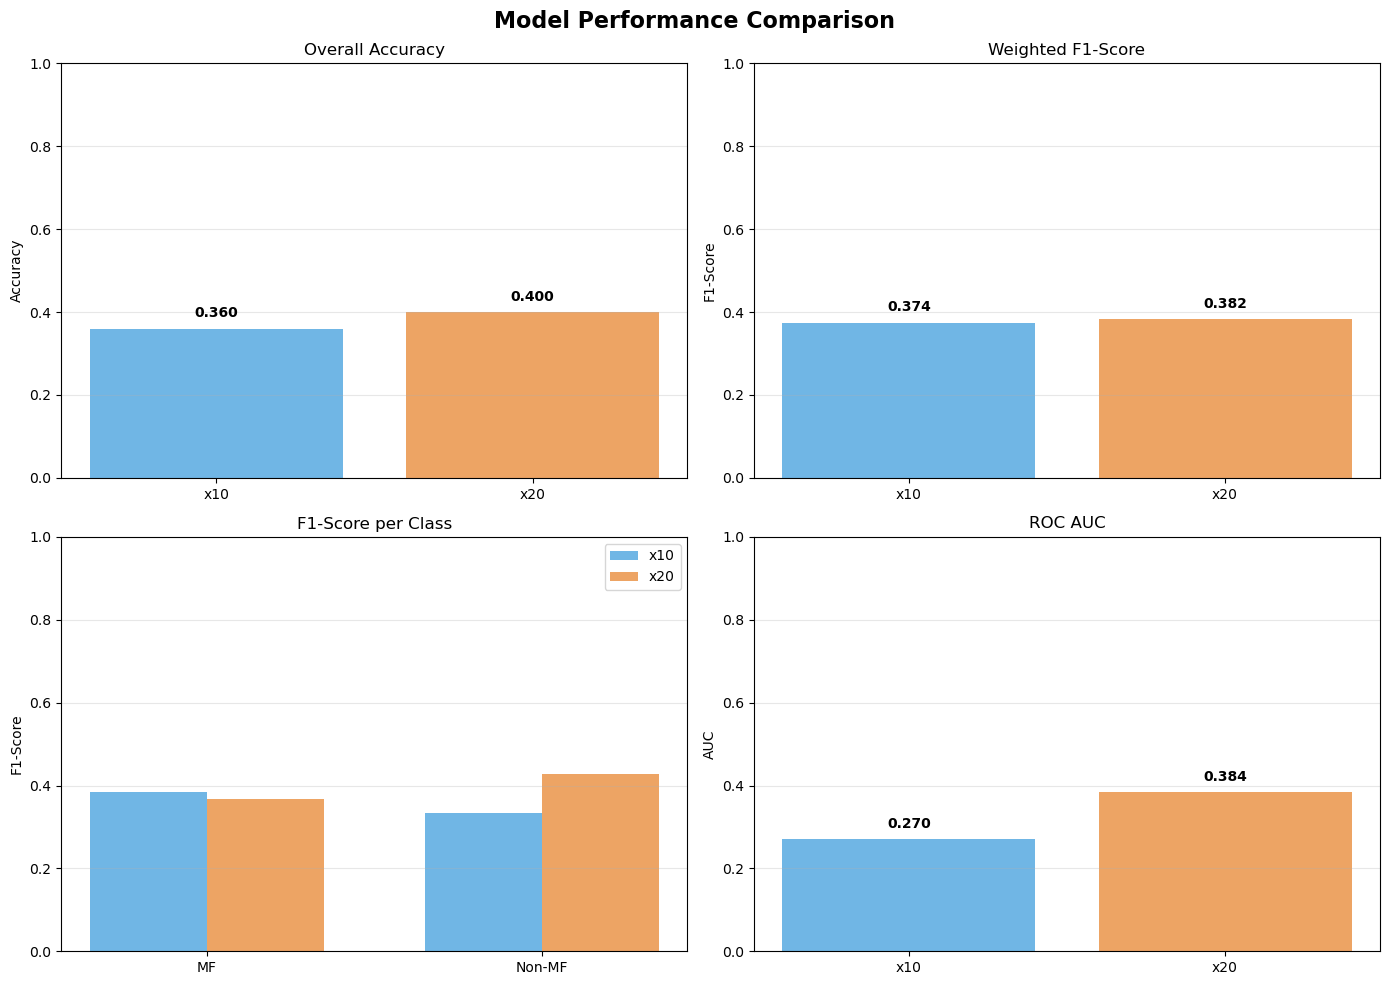

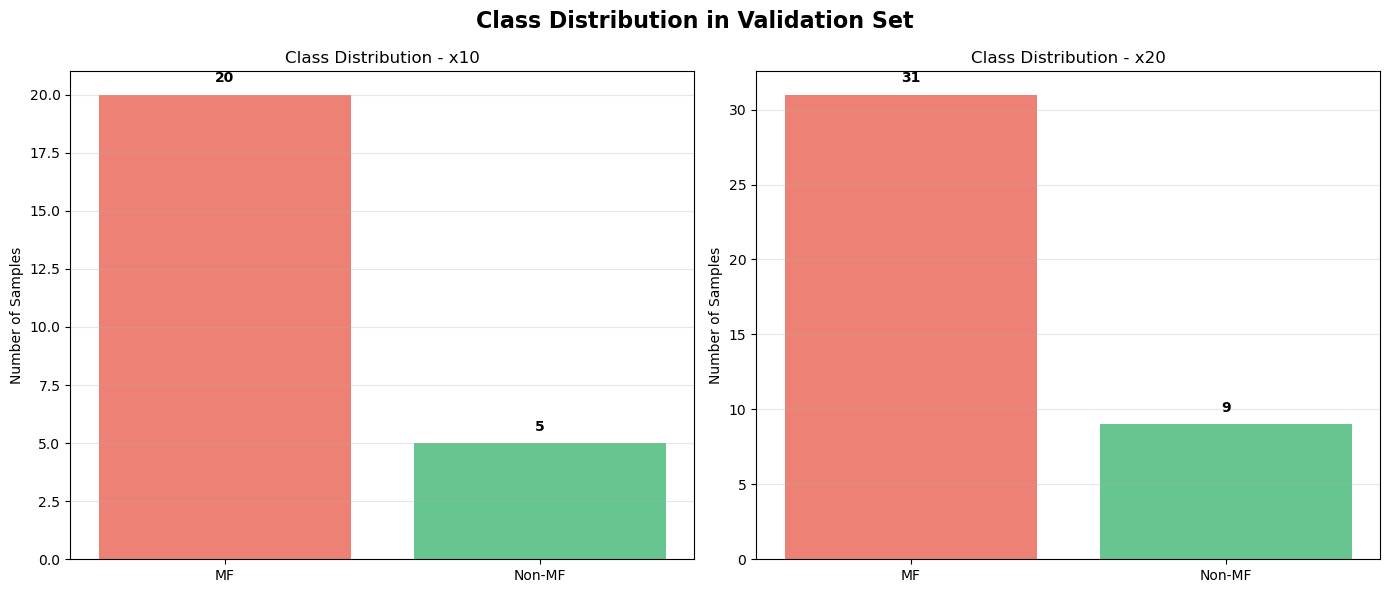


✓ All visualizations generated successfully!


In [12]:
# Cell 11 - Generate All Visualizations
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80 + "\n")

# 1. Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

plot_confusion_matrix(
    np.array(eval_x10['confusion_matrix']), 
    title='x10 Model', 
    ax=axes[0]
)
plot_confusion_matrix(
    np.array(eval_x20['confusion_matrix']), 
    title='x20 Model', 
    ax=axes[1]
)
plt.tight_layout()
plt.show()

# 2. ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))
plot_roc_curve(eval_x10, ax=ax)
plot_roc_curve(eval_x20, ax=ax)
ax.legend()
plt.tight_layout()
plt.show()

# 3. Precision-Recall Curves
fig, ax = plt.subplots(figsize=(10, 8))
plot_precision_recall_curve(eval_x10, ax=ax)
plot_precision_recall_curve(eval_x20, ax=ax)
ax.legend()
plt.tight_layout()
plt.show()

# 4. Metrics Comparison
fig = plot_metrics_comparison(eval_x10, eval_x20)
plt.show()

# 5. Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Class Distribution in Validation Set', fontsize=16, fontweight='bold')
plot_class_distribution(eval_x10, ax=axes[0])
plot_class_distribution(eval_x20, ax=axes[1])
plt.tight_layout()
plt.show()

print("\n✓ All visualizations generated successfully!")

In [13]:
# Cell 12 — Batch Test on Multiple Patients Using Weighted Fusion

label_map = {0: "MF", 1: "Non-MF"}

print("\n" + "="*100)
print("BATCH TEST: WEIGHTED AND EQUAL-WEIGHT PREDICTION FOR MULTIPLE PATIENTS")
print("="*100)

for entry in test_patient_paths:
    patient_path = entry['path']
    expected_label = entry['expected_label']

    print("\n" + "-"*100)
    print(f"Patient: {patient_path.name}")
    print(f"Expected Label: {expected_label}")
    print("-"*100)

    # Collect images
    x10_folder = patient_path / "x10"
    x20_folder = patient_path / "x20"

    x10_images = list(x10_folder.glob("*.tif")) if x10_folder.exists() else []
    x20_images = list(x20_folder.glob("*.tif")) if x20_folder.exists() else []

    if not x10_images and not x20_images:
        print("No x10 or x20 images found. Skipping.")
        continue

    # Build dictionary for combined prediction
    img_paths_dict = {}
    if x10_images:
        img_paths_dict['x10'] = x10_images[0]   # first image for x10
    if x20_images:
        img_paths_dict['x20'] = x20_images[0]   # first image for x20

    # Run predictions
    res_equal = combined_prediction(img_paths_dict, model_10, model_20, device)
    res_weighted = combined_prediction_weighted(
        img_paths_dict, model_10, model_20, device,
        weight_x20=2.0, weight_x10=1.0
    )

    # Individual predictions
    x10_result = res_weighted['individual_results'].get('x10')
    x20_result = res_weighted['individual_results'].get('x20')

    # Output individual results
    print("\nIndividual Model Predictions:")
    if x10_result:
        pred10 = label_map[x10_result['pred']]
        conf10 = x10_result['prob'][x10_result['pred']]*100
        print(f"  x10: {pred10} ({conf10:.1f}% confidence)")
    else:
        print("  x10: no images")

    if x20_result:
        pred20 = label_map[x20_result['pred']]
        conf20 = x20_result['prob'][x20_result['pred']]*100
        print(f"  x20: {pred20} ({conf20:.1f}% confidence)")
    else:
        print("  x20: no images")

    # Combined results
    pred_equal = label_map[res_equal['pred']]
    conf_equal = res_equal['prob'][res_equal['pred']]*100

    pred_weighted = label_map[res_weighted['pred']]
    conf_weighted = res_weighted['prob'][res_weighted['pred']]*100

    print("\nCombined Predictions:")
    print(f"  Equal Weight (1:1): {pred_equal} ({conf_equal:.1f}% confidence)")
    print(f"  Weighted (2:1):     {pred_weighted} ({conf_weighted:.1f}% confidence)")

    # Probability breakdown
    print("\nProbability Breakdown:")
    print(f"  Equal (1:1):    MF={res_equal['prob'][0]*100:.1f}%, Non-MF={res_equal['prob'][1]*100:.1f}%")
    print(f"  Weighted (2:1): MF={res_weighted['prob'][0]*100:.1f}%, Non-MF={res_weighted['prob'][1]*100:.1f}%")

    # Comparison with expected
    print("\nComparison:")
    print(f"  Expected: {expected_label}")
    print(f"  Equal-weight Prediction:   {pred_equal}")
    print(f"  Weighted Prediction:       {pred_weighted}")



BATCH TEST: WEIGHTED AND EQUAL-WEIGHT PREDICTION FOR MULTIPLE PATIENTS

----------------------------------------------------------------------------------------------------
Patient: 61
Expected Label: MF
----------------------------------------------------------------------------------------------------

Individual Model Predictions:
  x10: MF (56.6% confidence)
  x20: MF (62.7% confidence)

Combined Predictions:
  Equal Weight (1:1): MF (59.6% confidence)
  Weighted (2:1):     MF (60.7% confidence)

Probability Breakdown:
  Equal (1:1):    MF=59.6%, Non-MF=40.4%
  Weighted (2:1): MF=60.7%, Non-MF=39.3%

Comparison:
  Expected: MF
  Equal-weight Prediction:   MF
  Weighted Prediction:       MF

----------------------------------------------------------------------------------------------------
Patient: 21
Expected Label: MF
----------------------------------------------------------------------------------------------------

Individual Model Predictions:
  x10: Non-MF (94.7% confidence

In [14]:
# Cell 13 - Save Evaluation Results
print("\n" + "="*80)
print("SAVING EVALUATION RESULTS")
print("="*80 + "\n")

# Prepare results for JSON (remove non-serializable objects)
def prepare_for_json(eval_results):
    results_clean = eval_results.copy()
    # Remove curve data (too large for JSON)
    results_clean['roc_curve'] = {
        'computed': eval_results['roc_curve']['fpr'] is not None
    }
    results_clean['pr_curve'] = {
        'computed': eval_results['pr_curve']['precision'] is not None
    }
    # Remove raw predictions (too large)
    del results_clean['y_true']
    del results_clean['y_pred']
    del results_clean['y_probs']
    del results_clean['patient_results']
    
    return results_clean

# Save to JSON
results_summary = {
    'x10_model': prepare_for_json(eval_x10),
    'x20_model': prepare_for_json(eval_x20),
    'model_paths': {
        'x10': f"model_{model_name_10x}_x10.pth",
        'x20': f"model_{model_name_20x}_x20.pth"
    },
    'weighted_prediction_config': {
        'x20_weight': 2.0,
        'x10_weight': 1.0,
        'rationale': 'x20 model has higher accuracy and reliability'
    }
}

with open('model_evaluation_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("✓ Saved: model_evaluation_results.json")

# Generate a summary report
report = f"""
MODEL EVALUATION REPORT
{'='*80}

Evaluation Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
Models Evaluated:
  - x10: {model_name_10x}
  - x20: {model_name_20x}

{'='*80}
PERFORMANCE METRICS
{'='*80}

x10 Model:
  Overall Accuracy: {eval_x10['accuracy']:.4f}
  Weighted F1-Score: {eval_x10['f1_weighted']:.4f}
  ROC AUC: {f"{eval_x10['roc_auc']:.4f}" if eval_x10.get('roc_auc') is not None else 'N/A'}
  
  MF Class:
    Precision: {eval_x10['precision_per_class'][0]:.4f}
    Recall: {eval_x10['recall_per_class'][0]:.4f}
    F1-Score: {eval_x10['f1_per_class'][0]:.4f}
  
  Non-MF Class:
    Precision: {eval_x10['precision_per_class'][1]:.4f}
    Recall: {eval_x10['recall_per_class'][1]:.4f}
    F1-Score: {eval_x10['f1_per_class'][1]:.4f}

x20 Model:
  Overall Accuracy: {eval_x20['accuracy']:.4f}
  Weighted F1-Score: {eval_x20['f1_weighted']:.4f}
  ROC AUC: {f"{eval_x20['roc_auc']:.4f}" if eval_x20.get('roc_auc') is not None else 'N/A'}
  
  MF Class:
    Precision: {eval_x20['precision_per_class'][0]:.4f}
    Recall: {eval_x20['recall_per_class'][0]:.4f}
    F1-Score: {eval_x20['f1_per_class'][0]:.4f}
  
  Non-MF Class:
    Precision: {eval_x20['precision_per_class'][1]:.4f}
    Recall: {eval_x20['recall_per_class'][1]:.4f}
    F1-Score: {eval_x20['f1_per_class'][1]:.4f}

{'='*80}
WEIGHTED PREDICTION CONFIGURATION
{'='*80}

For combined x10 + x20 predictions:
  x20 weight: 2.0 (66.7% influence)
  x10 weight: 1.0 (33.3% influence)

Rationale:
  - x20 model shows {'higher' if eval_x20['accuracy'] > eval_x10['accuracy'] else 'comparable'} accuracy
  - x20 provides more detailed tissue information
  - 2:1 weighting gives precedence to x20 while still considering x10

{'='*80}
GENERATED FILES
{'='*80}

Visualizations:
  - confusion_matrices.png
  - roc_curves.png
  - precision_recall_curves.png
  - metrics_comparison.png
  - class_distribution.png

Data:
  - model_evaluation_results.json
  - model_evaluation_report.txt (this file)

{'='*80}
"""

with open('model_evaluation_report.txt', 'w') as f:
    f.write(report)

print("✓ Saved: model_evaluation_report.txt")
print("\n" + "="*80)
print("EVALUATION COMPLETE!")
print("="*80)
print("\nGenerated Files:")
print("  📄 model_evaluation_results.json")
print("  📄 model_evaluation_report.txt")
print("\nYou can now use combined_prediction_weighted() for 2:1 weighted predictions!")


SAVING EVALUATION RESULTS

✓ Saved: model_evaluation_results.json
✓ Saved: model_evaluation_report.txt

EVALUATION COMPLETE!

Generated Files:
  📄 model_evaluation_results.json
  📄 model_evaluation_report.txt

You can now use combined_prediction_weighted() for 2:1 weighted predictions!
